In [1]:
import numpy as np
from collections import OrderedDict
import numpy as np
import pandas as pd
import pymeasure
from time import sleep, time
from matplotlib import pyplot as plt
from matplotlib import style
from datetime import datetime
from pymeasure.instruments.keithley import Keithley2400
from pymeasure.instruments.keithley import Keithley2000
import matplotlib.cm as cm
from glob import glob
import os
import sys

In [2]:
currentsource_gating = Keithley2400(4)

In [45]:
desiredvoltage = -75
currentsource_gating.ramp_to_voltage(desiredvoltage, steps=60, pause=0.2)

In [58]:
currentsource_gating.current

2.401768e-11

In [54]:
currentsource_gating.source_voltage

75.0

In [33]:
def gating_rxx(Vmin, Vmax, Vstep,delay, average,file_path,sample_name):
    VdataPoints= int(np.absolute(Vmax-Vmin)/Vstep)+1
    voltage = np.linspace(Vmin,Vmax,num=VdataPoints)
    data = OrderedDict()
    data['Voltage'], data['leakage'] = [], []
    filename = file_path+'gating2point'+sample_name+'.csv'
    
    if np.absolute(Vmin/VdataPoints) > 0.1:
        currentsource_gating.ramp_to_voltage(Vmin, steps = int(np.absolute(Vmin/0.25)), pause=0.3)    
    # Set the ramp rate to Vmin
    print ('waiting for initial voltage')
    while abs(currentsource_gating.source_voltage - Vmin)>0.5:
        sleep(3)
    print ('Intial voltage set at : ' + str(Vmin))
    sleep(delay)
    for i in voltage:
        currentsource_gating.ramp_to_voltage(i, steps = int(Vstep/0.25)+1, pause=0.3)# 0.25V/sec
        while abs(currentsource_gating.source_voltage - i)>0.5:
            sleep(1)
        sleep(delay)
        print ('Voltage : ' + str(i) + ' checked and stabilized')
        
        data['Voltage'].append(i)
        current = currentsource_gating.current
        print('Current : ' + str(current) + 'A')
        data['leakage'].append(current)
        
        plt.plot(data['Voltage'], data['leakage'])
        plt.xlabel('Gate Voltage',fontsize=18)
        plt.ylabel('Leakage',fontsize=18)
        
        print('Measurement done for voltage : ' + str(currentsource_gating.source_voltage))
        dataset = pd.DataFrame({ 'Voltage': np.transpose(data['Voltage']), 'leakage':np.transpose(data['leakage'])})
        #save dataframe to csv file in the same path and file name
        dataset.to_csv(filename,index=False)

    #reset voltage after experiment
    currentsource_gating.ramp_to_voltage(0, steps = int(VdataPoints), pause=0.2)


In [7]:
# currentsource_gating.current

waiting for initial voltage
Intial voltage set at : 50
Voltage : 50.0 checked and stabilized
Current : 1.478937e-11A
Measurement done for voltage : 50.0
Voltage : 45.0 checked and stabilized
Current : 1.444594e-11A
Measurement done for voltage : 45.0
Voltage : 40.0 checked and stabilized
Current : 1.413136e-11A
Measurement done for voltage : 40.0
Voltage : 35.0 checked and stabilized
Current : 1.375132e-11A
Measurement done for voltage : 35.0
Voltage : 30.0 checked and stabilized
Current : 1.342546e-11A
Measurement done for voltage : 30.0
Voltage : 25.0 checked and stabilized
Current : 1.343813e-11A
Measurement done for voltage : 25.0
Voltage : 20.0 checked and stabilized
Current : 1.316013e-11A
Measurement done for voltage : 20.0
Voltage : 15.0 checked and stabilized
Current : 1.282372e-11A
Measurement done for voltage : 15.0
Voltage : 10.0 checked and stabilized
Current : 1.268437e-11A
Measurement done for voltage : 10.0
Voltage : 5.0 checked and stabilized
Current : 1.28195e-11A
Mea

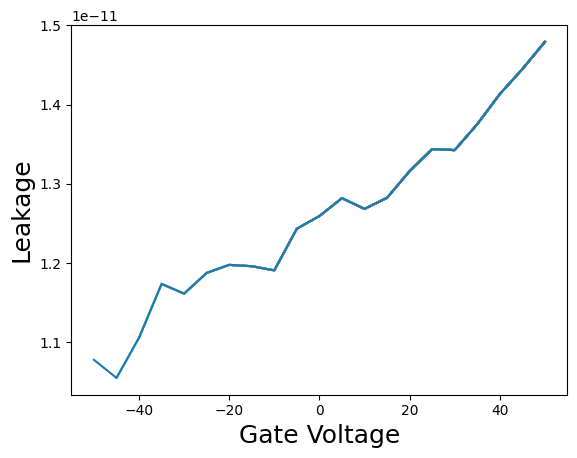

In [34]:
file_path='C:/Users/Ralph Group/Documents/Data/TiffanyFilms/NiFerritePostPaterning/IV/'
sample_name='2450_highvoltage_run6'
average = 1
gating_rxx(50, -50, 5, 1, average,file_path,sample_name)

In [ ]:
# currentsource_gating.current

In [ ]:
# df = pd.read_csv('C:/Users/Ralph Group/Documents/Data/TiffanyFilms/NiFerritePostPaterning/IV/gating2pointVoltageVSCurrent.csv')
# plt.plot(df['Voltage'], df['leakage'])